# Processamento

In [3]:
import re
import math
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from IPython.display import display
from plotly.subplots import make_subplots
import plotly.io as pio 
pio.renderers.default = "vscode"

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import NearestCentroid
from sklearn.metrics import recall_score, ConfusionMatrixDisplay, confusion_matrix, f1_score
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import AdaBoostClassifier

from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier

# Caminhos de entrada
XLSX1_PATH = "../Datos_Anonimo_20231_v2.xlsx"  # 1º semestre
XLSX2_PATH = "../Datos_Anonimo_20232_v2.xlsx"  # 2º semestre
SHEET_INDEX = 1  # segunda aba

In [4]:
# Renomeação de colunas ES -> PT (sem acentos nos nomes de colunas para evitar problemas)
rename_map = {
    "Periodo": "Periodo",
    "Grupo": "Grupo",
    "Horario": "Horario",
    "Tipo_Documento": "Tipo_Documento",
    "Edad": "Idade",
    "Genero": "Genero",
    "STEM": "STEM",
    "MejoraNotaQuices": "MelhoraNotaQuizzes",
    "Calificación_Oficial": "Nota_Oficial",
    "Aprobo": "Aprovou",
    "Nombre_Programa_Academico": "Nome_Programa_Academico",
    "Nombre_Programa_Académico": "Nome_Programa_Academico",
    "Proyecto_Parte1": "Projeto_Parte1",
    "Proyecto_Parte2": "Projeto_Parte2",
    "Talleres": "Oficinas",
    "Quices": "Quizzes",
    "CalcNotaQuiz": "CalcNotaQuiz",
    "Parcial_1": "Parcial_1",
    "Parcial_2": "Parcial_2",
    "Quiz1": "Quiz1",
    "Quiz2": "Quiz2",
    "Quiz3": "Quiz3",
    "Quiz4": "Quiz4",
    "Quiz5": "Quiz5",
    "Quiz6": "Quiz6",
    "Quiz7": "Quiz7",
    "Quiz8": "Quiz8",
    "Cuánto mejora?": "Quanto_Melhora",
    "Cuanto mejora?": "Quanto_Melhora",
}
# N mínimo prático para o dataset atual: 8 (fecha/tiempo 1..8)
for i in range(1, 9):
    rename_map[f"Fecha_Quiz{i}"] = f"Data_Quiz{i}"
    rename_map[f"TiempoQ{i}"] = f"TempoQ{i}"

MAPA_PROGRAMAS = {
    "COMUNICACIÓN SOCIAL": "Comunicacao Social",
    "DERECHO": "Direito",
    "INGENIERÍA CIVIL": "Engenharia Civil",
    "ADMINISTRACIÓN DE NEGOCIOS": "Administracao de Negocios",
    "INGENIERÍA DE DISEÑO DE PRODUCTO": "Engenharia de Design de Produto",
    "MERCADEO": "Marketing",
    "PSICOLOGÍA": "Psicologia",
    "INGENIERÍA FÍSICA": "Engenharia Fisica",
    "NEGOCIOS INTERNACIONALES": "Negocios Internacionais",
    "BIOLOGÍA": "Biologia",
    "CIENCIAS POLÍTICAS": "Ciencias Politicas",
    "ECONOMÍA": "Economia",
    "CONTADURÍA PÚBLICA": "Contabilidade Publica",
    "MÚSICA": "Musica",
    "LITERATURA": "Literatura",
    "INGENIERÍA DE PROCESOS": "Engenharia de Processos",
    "CONVENIO MOVILIDAD PREGRADO (CONVENIOS - MOVILIDAD NACIONAL - ASISTENTES PREGRADO)":
        "Convenio Mobilidade Graduacao (Convenios - Mobilidade Nacional - Assistentes Graduacao)",
}
MAPA_APROV = {"Aprobó": "Aprovou", "Reprobó": "Reprovou", "Aprobo": "Aprovou", "Reprobo": "Reprovou"}
MAPA_IDADE = {"Mayor": "Maior", "Menor": "Menor"}
MAPA_GENERO = {"femenino": "Feminino", "masculino": "Masculino", "Femenino": "Feminino", "Masculino": "Masculino"}

# Padronização de STEM para PT: "Sim" / "No"
MAPA_STEM = {
    "Sí": "Sim", "SÍ": "Sim", "si": "Sim", "SIM": "Sim", "Sim": "Sim",
    "YES": "Sim", "Yes": "Sim", "TRUE": "Sim", "True": "Sim", "1": "Sim",
    "No": "No", "NO": "No", "Nao": "No", "Não": "No", "nao": "No",
    "FALSE": "No", "False": "No", "0": "No",
}

ERROR_TOKENS = {
    "#ERROR!", "#DIV/0!", "#N/A", "#NAME?", "#NULL!", "#NUM!", "#VALUE!", "#REF!",
    "N/D", "N/A", "NA", "NaN", "nan", "None", "NONE"
}

In [5]:
# Limpar células com error
def replace_excel_errors(df, cols=None):
    df = df.copy()
    if cols is None:
        cols = df.select_dtypes(include="object").columns.tolist()
    for c in cols:
        if c in df.columns:
            df[c] = df[c].replace(list(ERROR_TOKENS), np.nan)
    return df

# Padronização do dataframe
def padroniza_df(df):
    df = df.copy().rename(columns=rename_map)
    df = replace_excel_errors(df)
    if "Nome_Programa_Academico" in df.columns:
        df["Nome_Programa_Academico"] = (
            df["Nome_Programa_Academico"].astype(str).str.strip().replace(MAPA_PROGRAMAS, regex=False)
        )
    if "Aprovou" in df.columns:
        df["Aprovou"] = df["Aprovou"].astype(str).str.strip().replace(MAPA_APROV, regex=False)
    if "Idade" in df.columns:
        df["Idade"] = df["Idade"].astype(str).str.strip().replace(MAPA_IDADE, regex=False)
    if "Genero" in df.columns:
        df["Genero"] = df["Genero"].astype(str).str.strip().replace(MAPA_GENERO, regex=False)
    if "STEM" in df.columns:
        mask = df["STEM"].notna()
        if mask.any():
            df.loc[mask, "STEM"] = df.loc[mask, "STEM"].astype(str).str.strip().replace(MAPA_STEM, regex=False)
    return df

# Regex para parse de tempo (ex.: "2 minutos 10 segundos")
_PATTERN_TEMPO = re.compile(
    r"^\s*(?:(\d+)\s*minuto(?:s)?)?\s*(?:(\d+)\s*segundo(?:s)?)?\s*$",
    re.IGNORECASE
)

# Normalização dos tempos
def parse_to_seconds(val):
    if pd.isna(val):
        return np.nan
    if isinstance(val, (int, float)) and not isinstance(val, bool):
        try:
            return int(val)
        except Exception:
            return np.nan
    if isinstance(val, str):
        s = val.strip()
        try:
            return int(float(s))
        except Exception:
            pass
        s_norm = s.replace(" e ", " ").replace(",", " ")
        m = _PATTERN_TEMPO.match(s_norm)
        if m:
            mins, secs = m.group(1), m.group(2)
            total = (int(mins) * 60 if mins else 0) + (int(secs) if secs else 0)
            return total if (mins or secs) else np.nan
        if ":" in s_norm:
            parts = [p.strip() for p in s_norm.split(":")]
            if len(parts) == 2 and all(p.isdigit() for p in parts):
                mm, ss = map(int, parts)
                return mm * 60 + ss
            if len(parts) == 3 and all(p.isdigit() for p in parts):
                hh, mm, ss = map(int, parts)
                return hh * 3600 + mm * 60 + ss
    return np.nan

# Padroniza as colunas de tempo
def converte_colunas_tempo(df):
    df = df.copy()
    cols_tempo = [c for c in df.columns if re.match(r"^(TempoQ|TiempoQ)\d+$", c)]
    for col in cols_tempo:
        df[col] = df[col].apply(parse_to_seconds)
    return df

# Remove os alunos faltantes
def filtra_alunos_presentes(df):
    df = df.copy()
    cols_data = [c for c in df.columns if re.match(r"^(Data_Quiz|Fecha_Quiz)\d+$", c)]
    if not cols_data:
        return df
    df_filtrado = df.dropna(subset=cols_data, how="all")
    df_filtrado = df_filtrado.drop(columns=cols_data)
    return df_filtrado

def remove_outliers(df, n_cols_per_row=3):
    df_numeric = df.select_dtypes(include=["number"])
    df_numeric = df_numeric.drop(columns=["Grupo"], errors="ignore")  # evita erro se não existir

    n_cols = len(df_numeric.columns)
    n_rows = math.ceil(n_cols / n_cols_per_row)

    # Normalizar os outliers (clip)
    for col in df_numeric.columns:
        Q1 = df_numeric[col].quantile(0.25)
        Q3 = df_numeric[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df_numeric[col] = df_numeric[col].clip(lower, upper)

    return df_numeric

def fit_onehot_encoder(df_cat, cat_cols):
    cat_cols_exist = [c for c in cat_cols if c in df_cat.columns]
    if not cat_cols_exist:
        return {"type": "none", "encoder": None, "columns": [], "cat_cols": []}
    X_fit = replace_excel_errors(df_cat[cat_cols_exist].copy(), cols=cat_cols_exist)
    X_fit = X_fit.fillna("MISSING").astype(str)
    try:
        from sklearn.preprocessing import OneHotEncoder
        try:
            enc = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
        except TypeError:
            enc = OneHotEncoder(sparse=False, handle_unknown="ignore")
        enc.fit(X_fit)
        cols = list(enc.get_feature_names_out(cat_cols_exist))
        return {"type": "sklearn", "encoder": enc, "columns": cols, "cat_cols": cat_cols_exist}
    except Exception:
        dummies = pd.get_dummies(X_fit, prefix=cat_cols_exist, dummy_na=False)
        cols = dummies.columns.tolist()
        return {"type": "pandas", "encoder": cols, "columns": cols, "cat_cols": cat_cols_exist}

def aplica_onehot(df, encoder_info):
    df = df.copy()
    if encoder_info["type"] == "none":
        return df
    cat_cols_exist = encoder_info["cat_cols"]
    X = replace_excel_errors(df[cat_cols_exist].copy(), cols=cat_cols_exist).fillna("MISSING").astype(str)
    if encoder_info["type"] == "sklearn":
        arr = encoder_info["encoder"].transform(X)
        encoded_df = pd.DataFrame(arr, columns=encoder_info["columns"], index=df.index)
        out = pd.concat([df.drop(columns=cat_cols_exist), encoded_df], axis=1)
    else:
        dummies_df = pd.get_dummies(X, prefix=cat_cols_exist, dummy_na=False)
        all_cols = encoder_info["columns"]
        for c in all_cols:
            if c not in dummies_df.columns:
                dummies_df[c] = 0
        dummies_df = dummies_df[all_cols]
        out = pd.concat([df.drop(columns=cat_cols_exist), dummies_df], axis=1)
    bad_cols = [c for c in out.columns if "#ERROR!" in c]
    if bad_cols:
        out = out.drop(columns=bad_cols)
    return out

def estatisticas_basicas(df):
    possiveis = [f"Quiz{i}" for i in range(1, 13)] + [f"TempoQ{i}" for i in range(1, 13)]
    possiveis += ["Oficinas", "Parcial_1", "Parcial_2", "CalcNotaQuiz", "Nota_Oficial"]
    cols_exist = [c for c in possiveis if c in df.columns]
    if not cols_exist:
        return pd.DataFrame()
    num_cols = [c for c in cols_exist if pd.api.types.is_numeric_dtype(df[c])]
    if not num_cols:
        return pd.DataFrame()
    return df[num_cols].describe().copy()

In [6]:
from sklearn.model_selection import train_test_split

# 1) Carregar Excel
df1_raw = pd.read_excel(XLSX1_PATH, sheet_name=SHEET_INDEX)
df2_raw = pd.read_excel(XLSX2_PATH, sheet_name=SHEET_INDEX)

df1_treino, df1_teste = train_test_split(df1_raw, test_size = 0.2, random_state = 42)
df2_treino, df2_teste = train_test_split(df2_raw, test_size = 0.2, random_state = 42)
# 2) Padronizar valores/nomes
df1 = padroniza_df(df1_treino)
df2 = padroniza_df(df2_treino)


# 3) Converter tempos para segundos
df1 = converte_colunas_tempo(df1)
df2 = converte_colunas_tempo(df2)


# 4) Filtrar apenas alunos com algum quiz e remover colunas de datas
df1_presentes = filtra_alunos_presentes(df1)
df2_presentes = filtra_alunos_presentes(df2)

# 5) Concatenar
df_consolidado = pd.concat([df1_presentes, df2_presentes], ignore_index=True)

df_teste = pd.concat([df1_teste, df2_teste], ignore_index=True)
df_teste = padroniza_df(df_teste)

# 5.1) Limpar outliers das colunas numéricas
df_numeric_clean = remove_outliers(df_consolidado)  # faz clip nos outliers
# Substituir as colunas numéricas no df_consolidado
df_consolidado[df_numeric_clean.columns] = df_numeric_clean

# 6) Remover linhas com STEM ausente, replicando lógica original
if "STEM" in df_consolidado.columns:
    df_consolidado = df_consolidado.dropna(subset=["STEM"])

# 7) One-Hot
cat_cols = ["Tipo_Documento", "Idade", "Genero", "STEM", "MelhoraNotaQuizzes", "Aprovou"]
encoder_info = fit_onehot_encoder(df_consolidado, cat_cols)
df_onehot = aplica_onehot(df_consolidado, encoder_info)

encoder_info_teste = fit_onehot_encoder(df_teste, cat_cols)
df_teste = aplica_onehot(df_teste, encoder_info_teste)
df_teste = converte_colunas_tempo(df_teste)
df_teste = padroniza_df(df_teste)
# 8) Estatísticas
tabela_stats = estatisticas_basicas(df_consolidado)

# Amostras
print("df_consolidado:", df_consolidado.shape)
print("df_onehot:", df_onehot.shape)


df_consolidado: (1100, 34)
df_onehot: (1100, 42)


In [7]:
# Remoção segura: só dropa se existir
baselines = ["STEM_No", "MelhoraNotaQuizzes_False", "Idade_Menor", "Aprovou_Reprovou", 'Genero_Feminino']
drop_list = [c for c in baselines if c in df_onehot.columns]
df_onehot = df_onehot.drop(columns=drop_list)
print("Dummies baseline removidas:", drop_list)
print("df_onehot (após remoção):", df_onehot.shape)

df_onehot = df_onehot[['Tipo_Documento_CC','Tipo_Documento_CE','Tipo_Documento_PP','Tipo_Documento_TI',
                       'Idade_Maior', 'Genero_Masculino', 'STEM_SI', 'MelhoraNotaQuizzes_True', 'Aprovou_Aprovou']]


Dummies baseline removidas: ['STEM_No', 'MelhoraNotaQuizzes_False', 'Idade_Menor', 'Aprovou_Reprovou', 'Genero_Feminino']
df_onehot (após remoção): (1100, 37)


In [8]:
# seleciona todas as colunas de interesse
colunas = [
    "Quiz1", "TempoQ1", "Quiz2", "TempoQ2", "Quiz3", "TempoQ3", 
    "Quiz4", "TempoQ4", "Quiz5", "TempoQ5", "Quiz6", "TempoQ6", 
    "Quiz7", "TempoQ7", "Quiz8", "Nota_Oficial", 
    "Projeto_Parte1", "Projeto_Parte2", "Quanto_Melhora", "Oficinas", "Parcial_1",
    "Parcial_2"
]

# gera tabela descritiva
desc_tabela = df_consolidado[colunas].describe().T  # Transpõe para variáveis ficarem como linhas


In [9]:
# Escalonamento das variáveis testadas
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Criando cópia para não sobrescrever
df_scaled = df_consolidado.copy()

# ----------------------
# Padronização (Z-score)
# ----------------------
scaler_standard = StandardScaler()

# Calificacion_Oficial
df_scaled["Nota_Oficial"] = scaler_standard.fit_transform(
    df_consolidado[["Nota_Oficial"]]
)

# CalcNotaQuiz
df_scaled["CalcNotaQuiz_scaled"] = scaler_standard.fit_transform(
    df_consolidado[["CalcNotaQuiz"]]
)

# ----------------------
# Min-Max [0,1]
# ----------------------
scaler_minmax = MinMaxScaler()

# Talleres
df_scaled["Oficinas"] = scaler_minmax.fit_transform(
    df_consolidado[["Oficinas"]]
)

In [10]:
quizzes = ['Quiz1','Quiz2','Quiz3','Quiz4','Quiz5','Quiz6','Quiz7', "Parcial_1", "Parcial_2"]

for q in quizzes:
    df_scaled[q] = scaler_minmax.fit_transform(
        df_consolidado[[q]]
    )

tempo = ['TempoQ1','TempoQ2','TempoQ3','TempoQ4','TempoQ5','TempoQ6','TempoQ7']

for t in tempo:
    df_scaled[t] = scaler_minmax.fit_transform(
        df_consolidado[[t]]
    )

#Seleciona apenas as variáveis escalonadas para que depois se crie o df final
df_scaled = df_scaled[['Quiz1','Quiz2','Quiz3','Quiz4','Quiz5','Quiz6','Quiz7','TempoQ1','TempoQ2','TempoQ3',
                       'TempoQ4','TempoQ5','TempoQ6','TempoQ7',"Nota_Oficial","CalcNotaQuiz_scaled","Oficinas","Projeto_Parte1", "Projeto_Parte2","Parcial_1",
    "Parcial_2"]]

In [11]:
quizzes = ['Quiz1','Quiz2','Quiz3','Quiz4','Quiz5','Quiz6','Quiz7', "Parcial_1", "Parcial_2"]

for q in quizzes:
    df_teste[q] = scaler_minmax.fit_transform(
        df_teste[[q]]
    )

tempo = ['TempoQ1','TempoQ2','TempoQ3','TempoQ4','TempoQ5','TempoQ6','TempoQ7']

for t in tempo:
    df_teste[t] = scaler_minmax.fit_transform(
        df_teste[[t]]
    )

In [12]:
# Concatenando df escalado e df onehot
df_final = pd.concat([df_scaled, df_onehot], axis=1)
colunas_para_remover = ['Nota_Oficial', 'Tipo_Documento_CC','Tipo_Documento_CE','Tipo_Documento_PP','Tipo_Documento_TI']

# Removendo as colunas
df_final = df_final.drop(columns=colunas_para_remover)

df_teste = df_teste.drop(columns=colunas_para_remover)
# df_teste = pd.concat([df_scaled_teste, df_teste], axis =1)

In [13]:
df_final["Reprovou"] = df_final["Aprovou_Aprovou"].apply(lambda x: 0 if x == 1 else 1)
df_final.drop('Aprovou_Aprovou', axis  = 1, inplace = True)

df_teste["Reprovou"] = df_teste["Aprovou_Aprovou"].apply(lambda x: 0 if x == 1 else 1)
df_teste.drop('Aprovou_Aprovou', axis  = 1, inplace = True)

In [14]:
df_final1 = df_final[['Genero_Masculino','STEM_SI',  'Quiz1', 'Quiz2', 'Quiz3', 'TempoQ1', 'TempoQ2', 'TempoQ3', 'Reprovou']]

df_final2 = df_final[['Genero_Masculino','STEM_SI', 'Quiz1', 'Quiz2', 'Quiz3','Quiz4', 'TempoQ1', 'TempoQ2', 'TempoQ3','TempoQ4', 'Parcial_1', 'Reprovou']]

df_final3 = df_final[['Genero_Masculino','STEM_SI', 'Quiz1', 'Quiz2', 'Quiz3','Quiz4','Quiz5', 'Quiz6', 'TempoQ1', 'TempoQ2', 'TempoQ3','TempoQ4', 'TempoQ5', 'TempoQ6','Parcial_1' , 'Reprovou']]

In [15]:
df_teste1 = df_teste[['Genero_Masculino','STEM_SI',  'Quiz1', 'Quiz2', 'Quiz3', 'TempoQ1', 'TempoQ2', 'TempoQ3', 'Reprovou']]

df_teste2 = df_teste[['Genero_Masculino','STEM_SI', 'Quiz1', 'Quiz2', 'Quiz3','Quiz4', 'TempoQ1', 'TempoQ2', 'TempoQ3','TempoQ4', 'Parcial_1', 'Reprovou']]

df_teste3 = df_teste[['Genero_Masculino','STEM_SI', 'Quiz1', 'Quiz2', 'Quiz3','Quiz4','Quiz5', 'Quiz6', 'TempoQ1', 'TempoQ2', 'TempoQ3','TempoQ4', 'TempoQ5', 'TempoQ6','Parcial_1' , 'Reprovou']]

In [16]:
df1.to_csv('dados/dados_bruto_sem1.csv', index=False)
df2.to_csv('dados/dados_bruto_sem2.csv', index=False)
df_consolidado.to_csv('dados/dados_consolidado.csv', index=False)
df_onehot.to_csv('dados/dados_onehot.csv', index=False)
df_scaled.to_csv('dados/dados_escalado.csv', index=False)
df_final.to_csv('dados/dados_modelo.csv', index=False)

df_final1.to_csv('dados/dados_modelo1.csv', index=False)
df_final2.to_csv('dados/dados_modelo2.csv', index=False)
df_final3.to_csv('dados/dados_modelo3.csv', index=False)

df_teste1.to_csv('dados/dados_teste1.csv', index=False)
df_teste2.to_csv('dados/dados_teste2.csv', index=False)
df_teste3.to_csv('dados/dados_teste3.csv', index=False)


In [17]:
df1.head()

,Periodo,Grupo,Horario,Tipo_Documento,Idade,Genero,Nome_Programa_Academico,STEM,Parcial_1,Parcial_2,...,TempoQ6,Data_Quiz7,Quiz7,TempoQ7,Quiz8,CalcNotaQuiz,MelhoraNotaQuizzes,Quanto_Melhora,Nota_Oficial,Aprovou
231,2023-1,4,Miércoles de 03:00PM a 06:00PM,TI,Menor,Masculino,Administracao de Negocios,No,5.00,4.75,...,328,3 de May de 2023 16:47,3.75,354,5,4.25750,True,0.44250,4.8,Aprovou
55,2023-1,4,Miércoles de 03:00PM a 06:00PM,CC,Maior,Feminino,Administracao de Negocios,No,5.00,5.00,...,298,3 de May de 2023 16:48,5.00,361,5,3.51625,True,0.38375,4.3,Aprovou
404,2023-1,25,Miércoles de 12:00PM a 03:00PM,TI,Menor,Masculino,Administracao de Negocios,No,5.00,5.00,...,250,3 de May de 2023 13:32,2.29,210,5,3.99000,False,0.00000,4.7,Aprovou
591,2023-1,1,Jueves de 03:00PM a 06:00PM,CC,Maior,Masculino,Negocios Internacionais,No,3.75,3.00,...,600,4 de May de 2023 15:32,5.00,124,5,3.28125,False,0.00000,3.7,Aprovou
362,2023-1,18,Martes de 06:00AM a 09:00AM,CC,Maior,Feminino,Direito,No,4.59,4.64,...,97,2 de May de 2023 07:32,4.38,273,5,4.29750,True,0.19250,4.4,Aprovou


In [18]:
df2.head()

,Periodo,Grupo,Horario,Tipo_Documento,Idade,Genero,Nome_Programa_Academico,STEM,Parcial_1,Parcial_2,...,TempoQ6,Data_Quiz7,Quiz7,TempoQ7,Quiz8,CalcNotaQuiz,MelhoraNotaQuizzes,Quanto_Melhora,Nota_Oficial,Aprovou
209,2023-2,43,Martes de 03:00PM a 06:00PM,CC,Maior,Feminino,Comunicacao Social,No,5.0,5.0,...,214,24 de October de 2023 16:35,5.00,87,5,4.53125,True,0.46875,5.0,Aprovou
312,2023-2,38,Martes de 03:00PM a 06:00PM,CC,Maior,Feminino,Comunicacao Social,No,4.7,3.3,...,258,24 de October de 2023 16:31,3.75,231,5,4.14125,True,0.05875,4.5,Aprovou
513,2023-2,62,Viernes de 12:00PM a 03:00PM,CC,Maior,Feminino,Marketing,No,5.0,5.0,...,90,27 de October de 2023 13:34,5.00,85,5,5.00000,False,0.00000,5.0,Aprovou
462,2023-2,59,Viernes de 06:00PM a 09:00PM,TI,Menor,Masculino,Negocios Internacionais,No,5.0,5.0,...,139,27 de October de 2023 19:35,3.75,360,0,4.21875,False,0.00000,3.6,Aprovou
574,2023-2,47,Miércoles de 06:00AM a 09:00AM,CC,Maior,Feminino,Engenharia de Design de Produto,SI,5.0,4.6,...,101,25 de October de 2023 07:49,5.00,158,0,4.37500,True,0.02500,4.8,Aprovou


In [19]:
df_consolidado.head()

,Periodo,Grupo,Horario,Tipo_Documento,Idade,Genero,Nome_Programa_Academico,STEM,Parcial_1,Parcial_2,...,Quiz6,TempoQ6,Quiz7,TempoQ7,Quiz8,CalcNotaQuiz,MelhoraNotaQuizzes,Quanto_Melhora,Nota_Oficial,Aprovou
0,2023-1,4,Miércoles de 03:00PM a 06:00PM,TI,Menor,Masculino,Administracao de Negocios,No,5.00,4.75,...,3.750,328.0,3.75,354.0,5,4.25750,True,0.44250,4.8,Aprovou
1,2023-1,4,Miércoles de 03:00PM a 06:00PM,CC,Maior,Feminino,Administracao de Negocios,No,5.00,5.00,...,3.750,298.0,5.00,361.0,5,3.51625,True,0.38375,4.3,Aprovou
2,2023-1,25,Miércoles de 12:00PM a 03:00PM,TI,Menor,Masculino,Administracao de Negocios,No,5.00,5.00,...,1.875,250.0,2.29,210.0,5,3.99000,False,0.00000,4.7,Aprovou
3,2023-1,1,Jueves de 03:00PM a 06:00PM,CC,Maior,Masculino,Negocios Internacionais,No,3.75,3.00,...,1.875,578.5,5.00,124.0,5,3.28125,False,0.00000,3.7,Aprovou
4,2023-1,18,Martes de 06:00AM a 09:00AM,CC,Maior,Feminino,Direito,No,4.59,4.64,...,2.500,97.0,4.38,273.0,5,4.29750,True,0.19250,4.4,Aprovou


In [20]:
df_onehot.head()

,Tipo_Documento_CC,Tipo_Documento_CE,Tipo_Documento_PP,Tipo_Documento_TI,Idade_Maior,Genero_Masculino,STEM_SI,MelhoraNotaQuizzes_True,Aprovou_Aprovou
0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
2,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0
4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0


In [21]:
df_scaled.head()

,Quiz1,Quiz2,Quiz3,Quiz4,Quiz5,Quiz6,Quiz7,TempoQ1,TempoQ2,TempoQ3,...,TempoQ5,TempoQ6,TempoQ7,Nota_Oficial,CalcNotaQuiz_scaled,Oficinas,Projeto_Parte1,Projeto_Parte2,Parcial_1,Parcial_2
0,0.6,0.758974,1.0,0.73262,1.0,0.6,0.6000,0.173565,0.338525,0.542550,...,0.148916,0.539945,0.578512,0.764676,0.233982,1.000000,4.80,4.80,0.857143,0.750000
1,1.0,0.200000,0.0,0.73262,0.0,0.6,1.0000,0.694259,0.629283,1.000000,...,0.884072,0.484848,0.591368,0.018320,-0.752345,0.714286,4.00,4.00,0.857143,0.833333
2,1.0,0.841026,0.6,1.00000,1.0,0.0,0.1328,0.539386,0.134995,0.318408,...,0.375118,0.396694,0.314050,0.615405,-0.121961,0.942857,5.00,5.00,0.857143,0.833333
3,0.2,0.000000,1.0,0.73262,1.0,0.0,1.0000,0.125501,1.000000,0.620058,...,0.424128,1.000000,0.156107,-0.877308,-1.065042,0.964286,3.50,3.50,0.500000,0.166667
4,0.2,1.000000,1.0,1.00000,1.0,0.2,0.8016,0.237650,0.654206,0.628437,...,0.197926,0.115702,0.429752,0.167591,0.287207,0.785714,4.38,4.38,0.740000,0.713333


In [22]:
df1 = pd.read_csv('dados/dados_modelo1.csv')
df2 = pd.read_csv('dados/dados_modelo2.csv')
df3 = pd.read_csv('dados/dados_modelo3.csv')
df1_test = pd.read_csv('dados/dados_teste1.csv')
df2_test = pd.read_csv('dados/dados_teste2.csv')
df3_test = pd.read_csv('dados/dados_teste3.csv')

In [23]:
X1_train = df1.drop('Reprovou', axis = 1)
y1_train = df1['Reprovou']
# X1.drop('TempoQ3', axis = 1, inplace = True)

X2_train = df2.drop('Reprovou', axis = 1)
y2_train = df2['Reprovou']
# X2.drop('TempoQ3', axis = 1, inplace = True)

X3_train = df3.drop('Reprovou', axis = 1)
y3_train = df3['Reprovou']
# X3.drop('TempoQ3', axis = 1, inplace = True)

X1_test = df1_test.drop('Reprovou', axis = 1)
y1_test = df1_test['Reprovou']
# X1.drop('TempoQ3', axis = 1, inplace = True)

X2_test = df2_test.drop('Reprovou', axis = 1)
y2_test = df2_test['Reprovou']
# X2.drop('TempoQ3', axis = 1, inplace = True)

X3_test = df3_test.drop('Reprovou', axis = 1)
y3_test = df3_test['Reprovou']
# X3.drop('TempoQ3', axis = 1, inplace = True)

In [24]:
X1_train['TempoQ3'] = X1_train['TempoQ3'].fillna(0)
X2_train['TempoQ3'] = X2_train['TempoQ3'].fillna(0)
X3_train['TempoQ3'] = X3_train['TempoQ3'].fillna(0)

# XGBoost

In [80]:
def xgb_classifier(x_train, x_test, y_train, y_test):

    # Aplicando SMOTE apenas no treino
    sm = SMOTE(random_state=42)
    x_train, y_train = sm.fit_resample(x_train, y_train)

    # Definição do classificador com parâmetros default
    xgb = XGBClassifier(random_state=42)

    # Adição do GridSearchCV
    param_grid_xgb = {
        'n_estimators': [50,100, 200],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.01, 0.1, 0.001],
        "tree_method": ["auto"]
    }

    # Aplicação do GridSearch
    grid = GridSearchCV(xgb, param_grid_xgb, cv=5, scoring='recall')
    grid.fit(x_train, y_train)

    # Imprimindo os melhores parâmetros encontrados
    print("Melhores parâmetros encontrados:", grid.best_params_)
    
    # Previsões no conjunto de teste usando o MELHOR modelo encontrado pelo grid
    y_pred = grid.predict(x_test)

    # Apresentação das métricas obtidas:
    print("\n--- Métricas obtidas ---")

    # Obtenção do Recall
    recall = recall_score(y_test, y_pred, pos_label=1)
    print("Recall da classe 1 no teste: ", recall)
    # Obtenção do F1 Score
    f1score = f1_score(y_test, y_pred, pos_label=1)
    print("F1 Score da classe 1 no teste: ", f1score)

    # Matriz de confusão
    cm = confusion_matrix(y_test, y_pred, labels=[1,0])
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Reprovado (1)", "Aprovado (0)"]
    )
    disp.plot(cmap="Blues", values_format="d")

    plt.title("Matriz de Confusão - XGBClassifier")
    plt.show()


Melhores parâmetros encontrados: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'tree_method': 'auto'}

--- Métricas obtidas ---
Recall da classe 1 no teste:  0.7692307692307693
F1 Score da classe 1 no teste:  0.39603960396039606


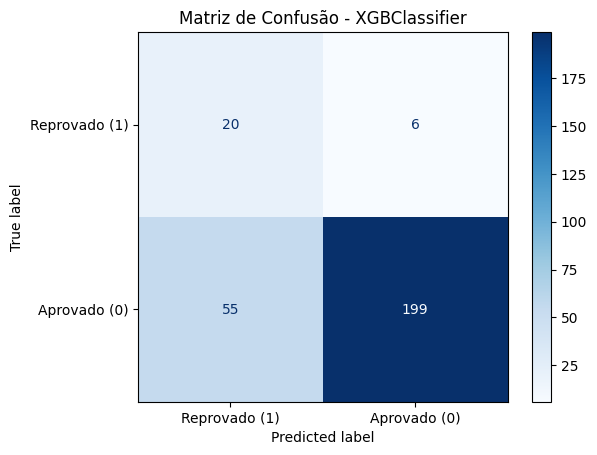

In [81]:
xgb_classifier(X1_train, X1_test, y1_train, y1_test)

Melhores parâmetros encontrados: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'tree_method': 'auto'}

--- Métricas obtidas ---
Recall da classe 1 no teste:  0.5384615384615384
F1 Score da classe 1 no teste:  0.5384615384615384


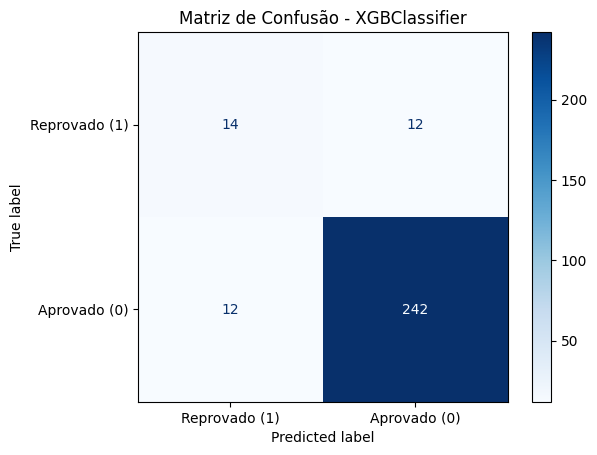

In [82]:
xgb_classifier(X2_train, X2_test, y2_train, y2_test)

Melhores parâmetros encontrados: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'tree_method': 'auto'}

--- Métricas obtidas ---
Recall da classe 1 no teste:  0.5384615384615384
F1 Score da classe 1 no teste:  0.5957446808510638


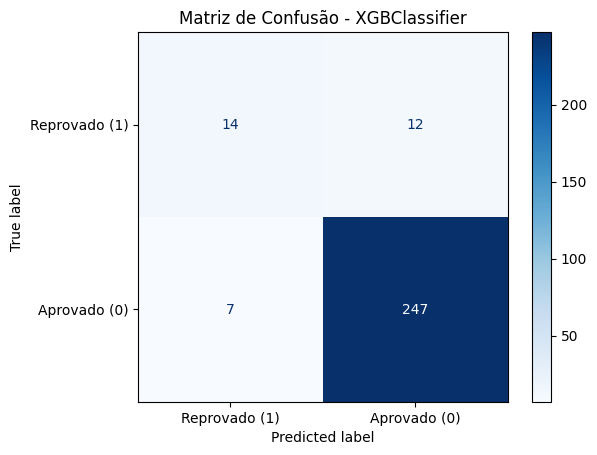

In [83]:
xgb_classifier(X3_train, X3_test, y3_train, y3_test)

# AdaBoost

In [91]:
def adaboost(x_train, x_test, y_train, y_test):
    # Se ainda não dividiu os dados
    # x_train, x_test, y_train, y_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

    # Aplicando SMOTE apenas no treino
    sm = SMOTE(random_state=42)
    x_train, y_train = sm.fit_resample(x_train, y_train)

    # Definição do classificador (parâmetros default)
    ab = AdaBoostClassifier(random_state=42)  # n_estimators=50, learning_rate=1.0

    # Parametros do GridSearchCV
    param_grid_ada = {
    'n_estimators': [50, 100, 200],     
    'learning_rate': [0.01, 0.1, 0.5],   
    'algorithm': ['SAMME'],                 
}

    
    # Aplicação do Grid SearchCv
    grid = GridSearchCV(ab, param_grid_ada, cv=5, scoring='recall', n_jobs=-1)
    grid.fit(x_train, y_train)

    # Imprimindo os melhores parâmetros que a busca encontrou
    print("Melhores parâmetros encontrados:", grid.best_params_)

    # Previsões no conjunto de teste usando o melhor modelo
    y_pred = grid.predict(x_test)   

    # Obtenção do Recall
    recall = recall_score(y_test, y_pred, pos_label=1)
    print("Recall da classe 1 no teste: ", recall)
    # Obtenção do F1 Score
    f1score = f1_score(y_test, y_pred, pos_label=1)
    print("F1 Score da classe 1 no teste: ", f1score)

    # Matriz de confusão
    cm = confusion_matrix(y_test, y_pred, labels=[1,0])
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Reprovado (1)", "Aprovado (0)"]
    )
    disp.plot(cmap="Blues", values_format="d")

    plt.title("Matriz de Confusão - AdaBoost")
    plt.show()

Melhores parâmetros encontrados: {'algorithm': 'SAMME', 'learning_rate': 0.1, 'n_estimators': 50}
Recall da classe 1 no teste:  0.8076923076923077
F1 Score da classe 1 no teste:  0.3387096774193548


c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning:

The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.



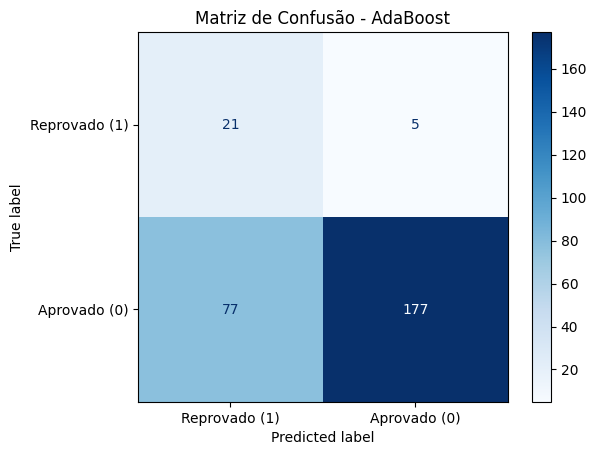

In [92]:
adaboost(X1_train, X1_test, y1_train, y1_test)

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning:

The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.



Melhores parâmetros encontrados: {'algorithm': 'SAMME', 'learning_rate': 0.01, 'n_estimators': 200}
Recall da classe 1 no teste:  0.6538461538461539
F1 Score da classe 1 no teste:  0.4594594594594595


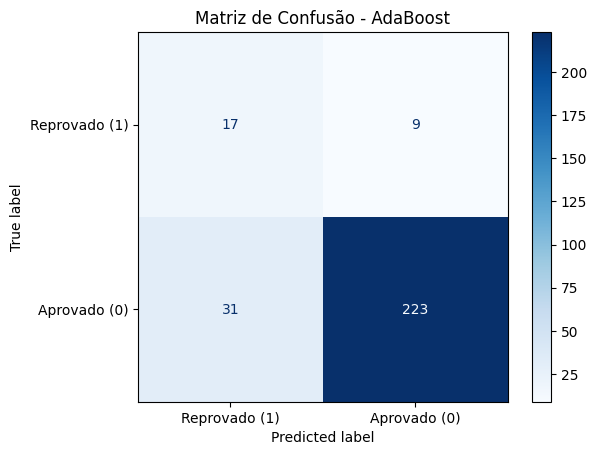

In [93]:
adaboost(X2_train, X2_test, y2_train, y2_test)

c:\Users\User\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning:

The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.



Melhores parâmetros encontrados: {'algorithm': 'SAMME', 'learning_rate': 0.01, 'n_estimators': 200}
Recall da classe 1 no teste:  0.6923076923076923
F1 Score da classe 1 no teste:  0.4931506849315068


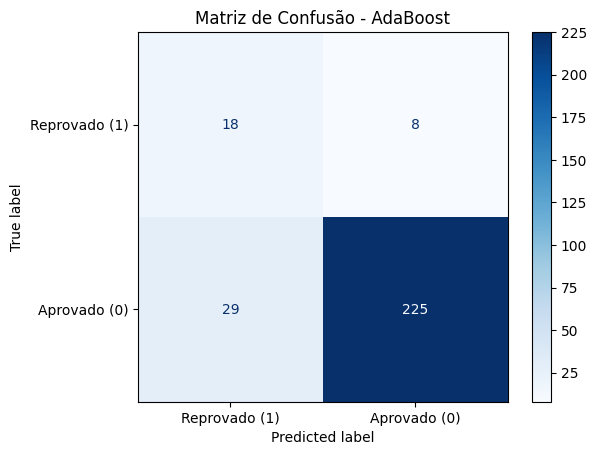

In [94]:
adaboost(X3_train, X3_test, y3_train, y3_test)